# Assignment 2 — Cross-Subject Mamba (Protocol-Based)

Cross-subject MEG brain-state decoding with a bidirectional Mamba model, run under the
shared protocol in `Assignment_2/docs/training_protocol.md` and
`Assignment_2/protocol_utils.py`.

All preprocessing, splitting, and metrics go through the single helper
`prepare_protocol_data`, so this notebook is comparable to any other model that uses the
same protocol. The model architecture is the only thing that differs.

Pipeline:

- Tune cross-subject hyperparameters with leave-one-subject-out (LOSO) validation over the
  two subjects in `Cross/train`, using **file-level accuracy** as the primary score.
- Retrain the selected config on both cross-train subjects for a fixed epoch count derived
  from the LOSO folds.
- Evaluate once on `test1/2/3` (three unseen subjects).

The intra-subject setting lives in a separate notebook.

## 1. Imports, protocol helpers, and configuration

In [9]:
%matplotlib inline
import os, sys, math, time, warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib-cache"))
os.environ.setdefault("XDG_CACHE_HOME", str(Path("/tmp") / "xdg-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

sys.path.append("..")
from protocol_utils import (
    CLASS_NAMES,
    DatasetPaths,
    PreprocessConfig,
    group_files_by_subject,
    list_files,
    prepare_protocol_data,
)

warnings.filterwarnings("ignore")
torch.manual_seed(0); np.random.seed(0)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("Device:", DEVICE)

def find_data_root():
    candidates = [Path("../data"), Path("Assignment_2/data"), Path.cwd() / "../data"]
    for p in candidates:
        if (p / "Cross" / "train").exists() and (p / "Intra" / "train").exists():
            return p
    raise FileNotFoundError("Could not locate Assignment_2/data")

paths = DatasetPaths(data_root=find_data_root())
BASE_PREPROCESS = PreprocessConfig(downsample_factor=4, window_size=512, stride=256)

BATCH_SIZE = 64
MAX_TUNE_EPOCHS = 30
TUNE_PATIENCE = 6
FINAL_EPOCH_CAP = 30
LABEL_SMOOTHING = 0.1

cross_train_files = list_files(paths.cross_train)
cross_by_subject = group_files_by_subject(cross_train_files)
cross_subjects = sorted(cross_by_subject)
cross_tests = {
    "test1": paths.cross_test1,
    "test2": paths.cross_test2,
    "test3": paths.cross_test3,
}
print("cross-train files:", len(cross_train_files))
print("cross subjects (LOSO folds):",
      [(s, len(cross_by_subject[s])) for s in cross_subjects])
print("preprocess:", BASE_PREPROCESS)

Device: mps
cross-train files: 64
cross subjects (LOSO folds): [('113922', 32), ('164636', 32)]
preprocess: PreprocessConfig(downsample_factor=4, window_size=512, stride=256, normalize=True, flat_sensor_std=1e-20)


## 2. Model and tuning candidates

In [10]:
@dataclass(frozen=True)
class Candidate:
    name: str
    preprocess: PreprocessConfig
    model_cfg: dict
    lr: float
    weight_decay: float
    dropout: float
    aug_noise: float
    aug_sensor_drop: float
    aug_time_mask: float


BASE_MODEL = dict(d_model=64, n_layers=2, d_state=16, d_conv=4, expand=2,
                  patch=8, stem_kernel=16)

TUNING_GRID = [
    Candidate(
        name="original_regularised",
        preprocess=BASE_PREPROCESS,
        model_cfg=BASE_MODEL,
        lr=1e-3,
        weight_decay=1e-2,
        dropout=0.30,
        aug_noise=0.10,
        aug_sensor_drop=0.10,
        aug_time_mask=0.10,
    ),
    Candidate(
        name="stronger_regularisation",
        preprocess=BASE_PREPROCESS,
        model_cfg=BASE_MODEL,
        lr=8e-4,
        weight_decay=2e-2,
        dropout=0.40,
        aug_noise=0.10,
        aug_sensor_drop=0.15,
        aug_time_mask=0.20,
    ),
    Candidate(
        name="lower_capacity",
        preprocess=BASE_PREPROCESS,
        model_cfg={**BASE_MODEL, "d_model": 48},
        lr=1e-3,
        weight_decay=2e-2,
        dropout=0.35,
        aug_noise=0.08,
        aug_sensor_drop=0.15,
        aug_time_mask=0.20,
    ),
    Candidate(
        name="gentler_augmentation",
        preprocess=BASE_PREPROCESS,
        model_cfg=BASE_MODEL,
        lr=1e-3,
        weight_decay=1e-2,
        dropout=0.30,
        aug_noise=0.05,
        aug_sensor_drop=0.05,
        aug_time_mask=0.05,
    ),
]

for c in TUNING_GRID:
    print(c)

Candidate(name='original_regularised', preprocess=PreprocessConfig(downsample_factor=4, window_size=512, stride=256, normalize=True, flat_sensor_std=1e-20), model_cfg={'d_model': 64, 'n_layers': 2, 'd_state': 16, 'd_conv': 4, 'expand': 2, 'patch': 8, 'stem_kernel': 16}, lr=0.001, weight_decay=0.01, dropout=0.3, aug_noise=0.1, aug_sensor_drop=0.1, aug_time_mask=0.1)
Candidate(name='stronger_regularisation', preprocess=PreprocessConfig(downsample_factor=4, window_size=512, stride=256, normalize=True, flat_sensor_std=1e-20), model_cfg={'d_model': 64, 'n_layers': 2, 'd_state': 16, 'd_conv': 4, 'expand': 2, 'patch': 8, 'stem_kernel': 16}, lr=0.0008, weight_decay=0.02, dropout=0.4, aug_noise=0.1, aug_sensor_drop=0.15, aug_time_mask=0.2)
Candidate(name='lower_capacity', preprocess=PreprocessConfig(downsample_factor=4, window_size=512, stride=256, normalize=True, flat_sensor_std=1e-20), model_cfg={'d_model': 48, 'n_layers': 2, 'd_state': 16, 'd_conv': 4, 'expand': 2, 'patch': 8, 'stem_kernel':

## 3. Mamba backend and classifier

In [11]:
try:
    from mamba_ssm import Mamba as _OfficialMamba
    HAS_OFFICIAL = True
except Exception as e:
    HAS_OFFICIAL = False
    print("Official mamba-ssm not available -> pure-PyTorch fallback. (", type(e).__name__, ")")

class RMSNorm(nn.Module):
    def __init__(self, d, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d))
    def forward(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight

class MambaBlock(nn.Module):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.d_inner = expand * d_model
        self.d_state = d_state
        self.dt_rank = math.ceil(d_model / 16)
        self.in_proj = nn.Linear(d_model, 2 * self.d_inner, bias=False)
        self.conv1d = nn.Conv1d(self.d_inner, self.d_inner, kernel_size=d_conv,
                                groups=self.d_inner, padding=d_conv - 1, bias=True)
        self.x_proj = nn.Linear(self.d_inner, self.dt_rank + 2 * d_state, bias=False)
        self.dt_proj = nn.Linear(self.dt_rank, self.d_inner, bias=True)
        A = torch.arange(1, d_state + 1, dtype=torch.float32).repeat(self.d_inner, 1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D = nn.Parameter(torch.ones(self.d_inner))
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
    def _ssm(self, x):
        A = -torch.exp(self.A_log)
        delta, B, C = self.x_proj(x).split([self.dt_rank, self.d_state, self.d_state], dim=-1)
        delta = F.softplus(self.dt_proj(delta))
        dA = torch.exp(torch.einsum("bld,dn->bldn", delta, A))
        dBx = torch.einsum("bld,bln,bld->bldn", delta, B, x)
        b, l, d = x.shape
        h = torch.zeros(b, d, self.d_state, device=x.device, dtype=x.dtype)
        ys = []
        for i in range(l):
            h = dA[:, i] * h + dBx[:, i]
            ys.append(torch.einsum("bdn,bn->bd", h, C[:, i]))
        return torch.stack(ys, dim=1) + x * self.D
    def forward(self, x):
        b, l, _ = x.shape
        xc, z = self.in_proj(x).chunk(2, dim=-1)
        xc = self.conv1d(xc.transpose(1, 2))[..., :l].transpose(1, 2)
        y = self._ssm(F.silu(xc)) * F.silu(z)
        return self.out_proj(y)

def make_mamba(d_model, d_state=16, d_conv=4, expand=2):
    if HAS_OFFICIAL and DEVICE.type == "cuda":
        return _OfficialMamba(d_model=d_model, d_state=d_state, d_conv=d_conv, expand=expand)
    return MambaBlock(d_model, d_state=d_state, d_conv=d_conv, expand=expand)

class BiMamba(nn.Module):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2, dropout=0.0):
        super().__init__()
        self.norm = RMSNorm(d_model)
        self.fwd = make_mamba(d_model, d_state, d_conv, expand)
        self.bwd = make_mamba(d_model, d_state, d_conv, expand)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        h = self.norm(x)
        return x + self.drop(self.fwd(h) + self.bwd(h.flip(1)).flip(1))

class MEGMambaClassifier(nn.Module):
    def __init__(self, n_sensors=248, n_classes=4, d_model=64, n_layers=2,
                 d_state=16, d_conv=4, expand=2, patch=8, stem_kernel=16, dropout=0.3):
        super().__init__()
        self.stem = nn.Conv1d(n_sensors, d_model, kernel_size=stem_kernel,
                              stride=patch, padding=stem_kernel // 2)
        self.stem_drop = nn.Dropout(dropout)
        self.layers = nn.ModuleList([
            BiMamba(d_model, d_state, d_conv, expand, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.norm_f = RMSNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(d_model, n_classes)
    def forward(self, x):
        x = self.stem(x).transpose(1, 2)
        x = self.stem_drop(x)
        for layer in self.layers:
            x = layer(x)
        return self.head(self.dropout(self.norm_f(x).mean(1)))

def build_model(candidate):
    return MEGMambaClassifier(**candidate.model_cfg, dropout=candidate.dropout)

for c in TUNING_GRID:
    m = build_model(c)
    print(c.name, "params:", round(sum(p.numel() for p in m.parameters()) / 1e3, 1), "K")
    del m
print("Backend:", "official mamba-ssm (CUDA)" if (HAS_OFFICIAL and DEVICE.type == "cuda")
      else "pure-PyTorch MambaBlock")

Official mamba-ssm not available -> pure-PyTorch fallback. ( ModuleNotFoundError )
original_regularised params: 385.0 K
stronger_regularisation params: 385.0 K
lower_capacity params: 269.6 K
gentler_augmentation params: 385.0 K
Backend: pure-PyTorch MambaBlock


## 4. Training and evaluation

In [12]:
def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=True):
    return DataLoader(TensorDataset(torch.from_numpy(X), torch.from_numpy(y)),
                      batch_size=batch_size, shuffle=shuffle, drop_last=False)

def augment_batch(xb, candidate):
    if candidate.aug_noise > 0:
        xb = xb + candidate.aug_noise * torch.randn_like(xb)
    if candidate.aug_sensor_drop > 0:
        keep = torch.rand(xb.size(0), xb.size(1), 1, device=xb.device) >= candidate.aug_sensor_drop
        xb = xb * keep.to(xb.dtype)
    if candidate.aug_time_mask > 0:
        L = xb.size(2)
        w = int(L * candidate.aug_time_mask)
        if w > 0:
            s = int(torch.randint(0, L - w + 1, (1,)).item())
            xb = xb.clone()
            xb[:, :, s:s + w] = 0.0
    return xb

def make_predict_logits(model):
    """Wrap a model as predict_logits(windows) -> (n_windows, n_classes), batched for memory.

    This is the contract ProtocolData.evaluate expects: windows shaped
    (n_windows, n_sensors, window_size) -> logits shaped (n_windows, n_classes).
    """
    @torch.no_grad()
    def predict_logits(windows):
        model.eval()
        out = []
        for i in range(0, len(windows), BATCH_SIZE):
            xb = torch.from_numpy(windows[i:i + BATCH_SIZE]).to(DEVICE)
            out.append(model(xb).cpu().numpy())
        return np.concatenate(out, axis=0)
    return predict_logits

def train_one_epoch(model, loader, candidate, optimizer, criterion):
    model.train()
    total_loss = total_correct = n = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        xb = augment_batch(xb, candidate)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        total_correct += (out.argmax(1) == yb).sum().item()
        n += xb.size(0)
    return total_loss / n, total_correct / n

def fit_loso_fold(candidate, held_subject, verbose=False):
    # One call prepares the fold: train on the other subject, validate on the held-out one.
    # test_files=held-out subject's files so data.evaluate() gives file-level val metrics.
    data = prepare_protocol_data(
        paths.cross_train,
        test_files=cross_by_subject[held_subject],
        config=candidate.preprocess,
        val_subject=held_subject,
    )
    loader = make_loader(data.X_train, data.y_train)
    model = build_model(candidate).to(DEVICE)
    predict = make_predict_logits(model)
    optimizer = torch.optim.AdamW(model.parameters(), lr=candidate.lr, weight_decay=candidate.weight_decay)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    best = {"epoch": 0, "file_acc": -1.0, "window_acc": -1.0}
    bad = 0
    history = []
    for epoch in range(1, MAX_TUNE_EPOCHS + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, loader, candidate, optimizer, criterion)
        val = data.evaluate(predict)
        history.append({"window_acc": val["window_acc"], "file_acc": val["file_acc"],
                        "epoch": epoch, "train_loss": train_loss, "train_acc": train_acc})
        improved = (
            val["file_acc"] > best["file_acc"] + 1e-4
            or (abs(val["file_acc"] - best["file_acc"]) <= 1e-4
                and val["window_acc"] > best["window_acc"] + 1e-4)
        )
        if improved:
            best = {"epoch": epoch, "file_acc": val["file_acc"], "window_acc": val["window_acc"]}
            bad = 0
        else:
            bad += 1
        if verbose:
            print(f"  ep {epoch:02d} train {train_loss:.3f}/{train_acc:.3f} "
                  f"val win/file {val['window_acc']:.3f}/{val['file_acc']:.3f} "
                  f"({time.time()-t0:.1f}s)")
        if bad >= TUNE_PATIENCE:
            break
    return best, history

def train_final(candidate, epochs):
    # val_frac=0 -> train on ALL cross-train subjects, no validation split.
    data = prepare_protocol_data(paths.cross_train, val_frac=0, config=candidate.preprocess)
    loader = make_loader(data.X_train, data.y_train)
    model = build_model(candidate).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=candidate.lr, weight_decay=candidate.weight_decay)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        loss, acc = train_one_epoch(model, loader, candidate, optimizer, criterion)
        print(f"final ep {epoch:02d}/{epochs:02d} train {loss:.3f}/{acc:.3f} ({time.time()-t0:.1f}s)")
    return model, data

## 5. LOSO hyperparameter tuning

In [13]:
tuning_results = []
for candidate in TUNING_GRID:
    print("=" * 72)
    print("candidate:", candidate.name)
    fold_rows = []
    for held_subject in cross_subjects:
        n_val = len(cross_by_subject[held_subject])
        print(f"held-out subject {held_subject}: "
              f"val_files={n_val} train_files={len(cross_train_files) - n_val}")
        best, history = fit_loso_fold(candidate, held_subject, verbose=True)
        fold_rows.append({
            "candidate": candidate.name,
            "held_subject": held_subject,
            "best_epoch": best["epoch"],
            "window_acc": best["window_acc"],
            "file_acc": best["file_acc"],
        })
        print(f"best {held_subject}: epoch={best['epoch']} "
              f"window={best['window_acc']:.3f} file={best['file_acc']:.3f}")
    mean_file = float(np.mean([r["file_acc"] for r in fold_rows]))
    mean_window = float(np.mean([r["window_acc"] for r in fold_rows]))
    median_epoch = int(np.median([r["best_epoch"] for r in fold_rows]))
    median_epoch = max(1, min(median_epoch, FINAL_EPOCH_CAP))
    tuning_results.append({
        "candidate": candidate,
        "folds": fold_rows,
        "mean_file_acc": mean_file,
        "mean_window_acc": mean_window,
        "final_epochs": median_epoch,
    })
    print(f"candidate summary: mean window={mean_window:.3f} "
          f"mean file={mean_file:.3f} final_epochs={median_epoch}")

tuning_results = sorted(
    tuning_results,
    key=lambda r: (r["mean_file_acc"], r["mean_window_acc"]),
    reverse=True,
)
print("\nRanking:")
for r in tuning_results:
    print(f"{r['candidate'].name:<24} file={r['mean_file_acc']:.3f} "
          f"window={r['mean_window_acc']:.3f} final_epochs={r['final_epochs']}")

best_result = tuning_results[0]
best_candidate = best_result["candidate"]
print("\nSelected:", best_candidate.name)

candidate: original_regularised
held-out subject 113922: val_files=32 train_files=32
  ep 01 train 1.503/0.295 val win/file 0.244/0.219 (14.4s)
  ep 02 train 1.402/0.303 val win/file 0.247/0.219 (11.8s)
  ep 03 train 1.366/0.327 val win/file 0.297/0.406 (11.6s)
  ep 04 train 1.159/0.526 val win/file 0.409/0.500 (11.1s)
  ep 05 train 0.951/0.648 val win/file 0.453/0.594 (11.6s)
  ep 06 train 0.783/0.798 val win/file 0.495/0.625 (11.5s)
  ep 07 train 0.594/0.902 val win/file 0.507/0.625 (11.7s)
  ep 08 train 0.470/0.968 val win/file 0.502/0.594 (11.3s)
  ep 09 train 0.420/0.991 val win/file 0.531/0.719 (10.9s)
  ep 10 train 0.401/0.995 val win/file 0.511/0.625 (11.3s)
  ep 11 train 0.403/0.991 val win/file 0.508/0.594 (11.5s)
  ep 12 train 0.403/0.990 val win/file 0.493/0.562 (12.2s)
  ep 13 train 0.398/0.994 val win/file 0.494/0.594 (11.5s)
  ep 14 train 0.384/0.998 val win/file 0.509/0.531 (11.6s)
  ep 15 train 0.377/1.000 val win/file 0.512/0.656 (11.1s)
best 113922: epoch=9 window=0.

## 6. Final retrain on both cross-train subjects

In [14]:
final_epochs = best_result["final_epochs"]
print("Training final model:", best_candidate.name, "epochs:", final_epochs)
final_model, final_data = train_final(best_candidate, final_epochs)

Training final model: gentler_augmentation epochs: 14
final ep 01/14 train 1.461/0.261 (17.6s)
final ep 02/14 train 1.283/0.385 (16.8s)
final ep 03/14 train 1.004/0.614 (16.9s)
final ep 04/14 train 0.810/0.758 (17.2s)
final ep 05/14 train 0.642/0.865 (16.9s)
final ep 06/14 train 0.526/0.931 (16.9s)
final ep 07/14 train 0.462/0.963 (17.0s)
final ep 08/14 train 0.437/0.980 (17.7s)
final ep 09/14 train 0.407/0.992 (17.4s)
final ep 10/14 train 0.408/0.991 (17.4s)
final ep 11/14 train 0.391/0.998 (19.0s)
final ep 12/14 train 0.388/0.997 (18.4s)
final ep 13/14 train 0.380/1.000 (17.8s)
final ep 14/14 train 0.376/1.000 (17.7s)


## 7. Cross test evaluation

In [15]:
predict_logits = make_predict_logits(final_model)
test_results = {}
for name, test_dir in cross_tests.items():
    test_results[name] = final_data.evaluate(predict_logits, test_files=test_dir)
    r = test_results[name]
    print(f"{name}: window-acc={r['window_acc']:.3f} file-acc={r['file_acc']:.3f}")

print("\nSetting             window-acc    file-acc")
print("------------------------------------------")
for name, r in test_results.items():
    print(f"Cross {name:<5}          {r['window_acc']:8.3f}    {r['file_acc']:8.3f}")
print(f"Cross mean              {np.mean([r['window_acc'] for r in test_results.values()]):8.3f}    "
      f"{np.mean([r['file_acc'] for r in test_results.values()]):8.3f}")

print("\nOriginal Mamba reference run:")
print("Cross test1              0.568       0.812")
print("Cross test2              0.523       0.688")
print("Cross test3              0.638       0.812")
print("Cross mean               0.576       0.771")

test1: window-acc=0.589 file-acc=0.812
test2: window-acc=0.545 file-acc=0.688
test3: window-acc=0.646 file-acc=0.812

Setting             window-acc    file-acc
------------------------------------------
Cross test1             0.589       0.812
Cross test2             0.545       0.688
Cross test3             0.646       0.812
Cross mean                 0.593       0.771

Original Mamba reference run:
Cross test1              0.568       0.812
Cross test2              0.523       0.688
Cross test3              0.638       0.812
Cross mean               0.576       0.771


## 8. Confusion matrix

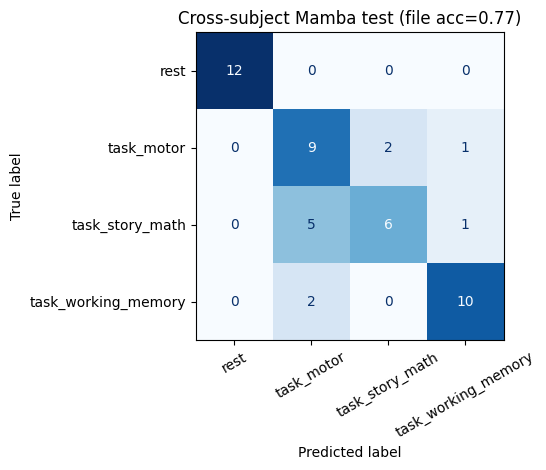

In [16]:
pooled_true = np.concatenate([r["file_y_true"] for r in test_results.values()])
pooled_pred = np.concatenate([r["file_y_pred"] for r in test_results.values()])
cm = np.zeros((4, 4), dtype=int)
for t, p in zip(pooled_true, pooled_pred):
    cm[int(t), int(p)] += 1
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    cmap="Blues", xticks_rotation=30, colorbar=False)
plt.title(f"Cross-subject Mamba test (file acc={(pooled_true == pooled_pred).mean():.2f})")
plt.tight_layout()
plt.show()